label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


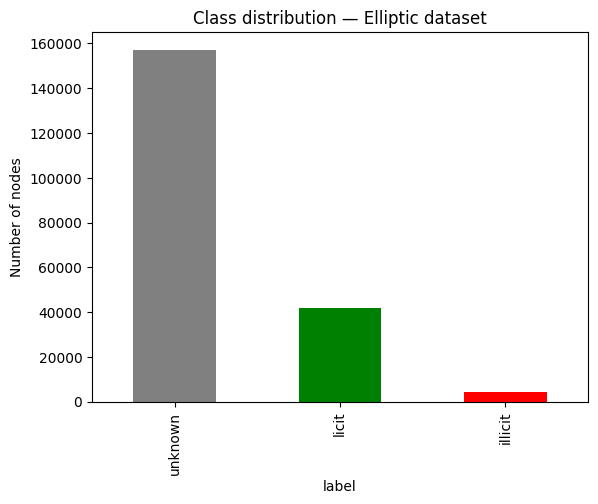

In [1]:
import matplotlib.pyplot as plt
from src.utils.load_data import build_merged_table

merged, edges = build_merged_table()

counts = merged["label"].value_counts().rename({1: "illicit", 0: "licit", -1: "unknown"})
print(counts)

counts.plot(kind="bar", color=["gray", "green", "red"])
plt.title("Class distribution — Elliptic dataset")
plt.ylabel("Number of nodes")
plt.show()

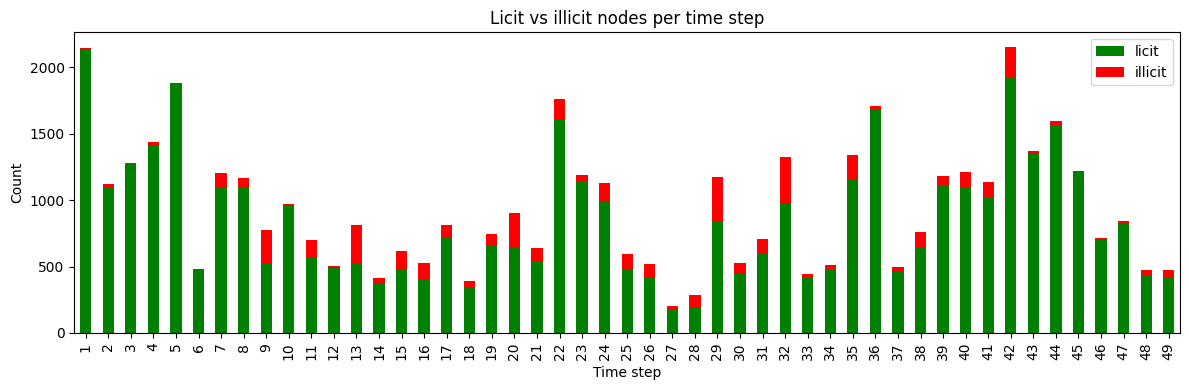

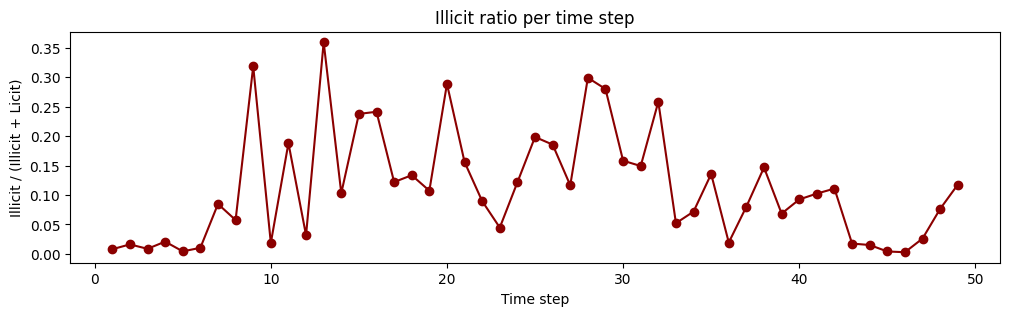

In [2]:
labeled = merged[merged["label"] != -1]

time_class = labeled.groupby("time_step")["label"].value_counts().unstack(fill_value=0)
time_class.columns = ["licit", "illicit"]
time_class["illicit_ratio"] = time_class["illicit"] / (time_class["licit"] + time_class["illicit"])

fig, ax1 = plt.subplots(figsize=(12, 4))
time_class[["licit", "illicit"]].plot(kind="bar", stacked=True, ax=ax1, color=["green", "red"])
ax1.set_title("Licit vs illicit nodes per time step")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Count")
plt.tight_layout()
plt.show()

time_class["illicit_ratio"].plot(figsize=(12, 3), marker="o", color="darkred")
plt.title("Illicit ratio per time step")
plt.xlabel("Time step")
plt.ylabel("Illicit / (Illicit + Licit)")
plt.show()

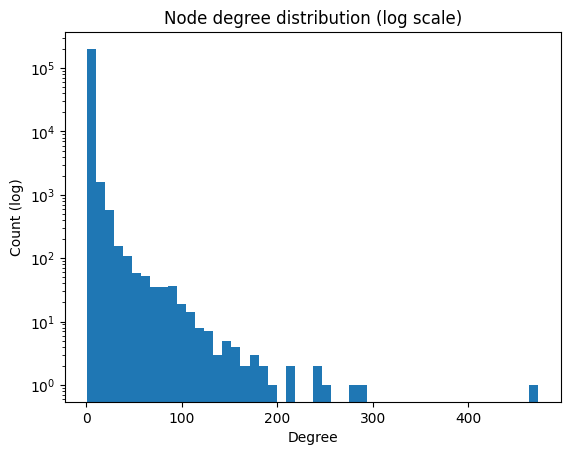

Mean degree: 2.3002026804862368
Max degree: 473


In [3]:
import networkx as nx
from src.utils.build_graph import build_pyg_graph

data = build_pyg_graph()

# Convert just the edge_index to a NetworkX graph for degree stats
# (don't do heavier NetworkX ops on the full graph -- 200K+ nodes will be slow)
import torch
edge_index_np = data.edge_index.numpy()
G = nx.DiGraph()
G.add_edges_from(zip(edge_index_np[0], edge_index_np[1]))

degrees = [d for _, d in G.degree()]
plt.hist(degrees, bins=50, log=True)
plt.title("Node degree distribution (log scale)")
plt.xlabel("Degree")
plt.ylabel("Count (log)")
plt.show()

print("Mean degree:", sum(degrees) / len(degrees))
print("Max degree:", max(degrees))

In [4]:
import numpy as np

deg_dict = dict(G.degree())
merged_idx = merged.reset_index(drop=True)
merged_idx["degree"] = merged_idx.index.map(lambda i: deg_dict.get(i, 0))

for label, name in [(1, "illicit"), (0, "licit"), (-1, "unknown")]:
    subset = merged_idx[merged_idx["label"] == label]["degree"]
    print(f"{name}: mean degree = {subset.mean():.2f}, median = {subset.median():.1f}")

illicit: mean degree = 2.01, median = 1.0
licit: mean degree = 3.10, median = 2.0
unknown: mean degree = 2.10, median = 2.0
